In [ ]:
# 1. Setup the new Kaggle API Token directly
!mkdir -p ~/.kaggle
!echo "KGAT_9b09a664e961bfe1901526ae8966adfe" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 2. Download and unzip the dataset
!kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign
!unzip -q skin-cancer-malignant-vs-benign.zip -d dataset/

print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign
License(s): unknown
skin-cancer-malignant-vs-benign.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset/data/test/benign/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace dataset/data/test/benign/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset downloaded and unzipped successfully!


Found 1197 malignant images for GAN training.
TensorFlow Dataset is successfully prepared and batched!


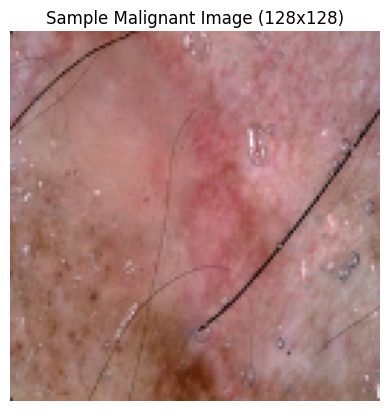

In [ ]:
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define the path to the malignant images in the training set
malignant_dir = '/content/dataset/train/malignant'
image_paths = glob.glob(os.path.join(malignant_dir, '*.jpg'))

print(f"Found {len(image_paths)} malignant images for GAN training.")

# 2. Function to load, resize, and normalize images
def load_and_preprocess(path):
    # Read the image file
    image = tf.io.read_file(path)
    # Decode the JPEG format to a tensor with 3 color channels (RGB)
    image = tf.image.decode_jpeg(image, channels=3)
    # Resize the image to 128x128 pixels to reduce computational load
    image = tf.image.resize(image, [128, 128])
    # Normalize pixel values from [0, 255] to [-1, 1] (Crucial for GANs)
    image = (image - 127.5) / 127.5
    return image

# 3. Create the TensorFlow Dataset pipeline
BATCH_SIZE = 32

dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow Dataset is successfully prepared and batched!")

# 4. (Optional) Display one processed image to verify
sample_images = next(iter(dataset))
plt.imshow((sample_images[0].numpy() * 127.5 + 127.5).astype("uint8"))
plt.title("Sample Malignant Image (128x128)")
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Build the Generator (The "Artist")
# It takes random noise (numbers) and turns them into an image
def build_generator():
    model = Sequential()

    # Input layer: Takes 100 random numbers
    model.add(layers.Input(shape=(100,)))

    # Hidden layers: Very simple Dense layers with standard ReLU
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(512, activation='relu'))

    # Output layer: Creates the pixels for a 128x128 RGB image
    # 'tanh' is used because our image pixels are scaled between -1 and 1
    model.add(layers.Dense(128 * 128 * 3, activation='tanh'))

    # Reshape the long list of pixels into a proper 2D image shape
    model.add(layers.Reshape((128, 128, 3)))

    return model

# 2. Build the Discriminator (The "Judge")
# It looks at an image and guesses if it is Real (1) or Fake (0)
def build_discriminator():
    model = Sequential()

    # Input layer: Takes a 128x128 RGB image
    model.add(layers.Input(shape=(128, 128, 3)))

    # Flatten: Turns the image into a long 1D list of numbers
    model.add(layers.Flatten())

    # Hidden layers: Simple Dense layers
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))

    # Output layer: 1 single number (Probability)
    # 'sigmoid' is used to output a value between 0 (Fake) and 1 (Real)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Create the models
generator = build_generator()
discriminator = build_discriminator()

print(" Vanilla GAN models created successfully!")
print("Generator output shape:", generator.output_shape)
print("Discriminator output shape:", discriminator.output_shape)

 Vanilla GAN models created successfully!
Generator output shape: (None, 128, 128, 3)
Discriminator output shape: (None, 1)


In [ ]:
import numpy as np

# 1. Setup Optimizers (The tools that update the models' weights)
# Adam optimizer is standard, learning rate is kept low for stability
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)

# Loss function (Binary Crossentropy to calculate 0 vs 1 errors)
loss_fn = tf.keras.losses.BinaryCrossentropy()

# 2. Define the Custom Training Step
# The @tf.function decorator makes the training run much faster
@tf.function
def train_step(real_images):
    # Get batch size dynamically
    batch_size = tf.shape(real_images)[0]

    # Create random noise for the Generator
    random_noise = tf.random.normal(shape=(batch_size, 100))

    # Train both models using GradientTape
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generator creates fake images
        fake_images = generator(random_noise, training=True)

        # Discriminator evaluates both real and fake images
        real_predictions = discriminator(real_images, training=True)
        fake_predictions = discriminator(fake_images, training=True)

        # Calculate Discriminator Loss
        # Real images should be close to 1, Fake images close to 0
        loss_disc_real = loss_fn(tf.ones_like(real_predictions), real_predictions)
        loss_disc_fake = loss_fn(tf.zeros_like(fake_predictions), fake_predictions)
        total_disc_loss = loss_disc_real + loss_disc_fake

        # Calculate Generator Loss
        # Generator wants the Discriminator to guess 1 (Real) for its fake images
        gen_loss = loss_fn(tf.ones_like(fake_predictions), fake_predictions)

    # Calculate gradients (how much to change the weights)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(total_disc_loss, discriminator.trainable_variables)

    # Apply the updates to the models
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, total_disc_loss

# 3. The Main Training Loop
EPOCHS = 5 # Set to a low number just to test if it works

print(f"Starting training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    gen_loss_avg = 0
    disc_loss_avg = 0
    batches = 0

    # Iterate over the dataset batches
    for image_batch in dataset:
        g_loss, d_loss = train_step(image_batch)
        gen_loss_avg += g_loss
        disc_loss_avg += d_loss
        batches += 1

    # Print the average loss at the end of each epoch
    print(f"Epoch {epoch + 1}/{EPOCHS} - Generator Loss: {gen_loss_avg/batches:.4f} - Discriminator Loss: {disc_loss_avg/batches:.4f}")

print(" Training loop finished successfully!")

Starting training for 5 epochs...
Epoch 1/5 - Generator Loss: 2.1271 - Discriminator Loss: 0.6416
Epoch 2/5 - Generator Loss: 7.3535 - Discriminator Loss: 0.0094


In [ ]:
import matplotlib.pyplot as plt

# 1. Create random noise for 4 images
test_noise = tf.random.normal([4, 100])

# 2. Ask the Generator to draw images based on this noise
generated_images = generator(test_noise, training=False)

# 3. Display the 4 fake images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    # Convert pixels back to [0, 255] to display them correctly
    img = (generated_images[i].numpy() * 127.5 + 127.5).astype('uint8')
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Fake Image {i+1}")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

EPOCHS = 100

print(f"Starting training for {EPOCHS} epochs... This might take a few minutes! ☕")

# 1. Create a fixed set of noise (so we can watch how the SAME 4 images evolve over time)
fixed_noise = tf.random.normal([4, 100])

# 2. Start the main training loop
for epoch in range(EPOCHS):
    gen_loss_avg = 0
    disc_loss_avg = 0
    batches = 0

    # Iterate over the dataset batches
    for image_batch in dataset:
        # train_step is the function we defined earlier
        g_loss, d_loss = train_step(image_batch)
        gen_loss_avg += g_loss
        disc_loss_avg += d_loss
        batches += 1

    # Print the average loss at the end of each epoch
    print(f"Epoch {epoch + 1}/{EPOCHS} - Generator Loss: {gen_loss_avg/batches:.4f} - Discriminator Loss: {disc_loss_avg/batches:.4f}")

    # 3. Show the generated images every 20 epochs to track progress
    if (epoch + 1) % 20 == 0:
        print(f"\n--- Visualizing Progress at Epoch {epoch + 1} ---")

        # Ask the Generator to draw using the fixed noise
        generated_images = generator(fixed_noise, training=False)

        # Display the 4 fake images
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for i in range(4):
            # Convert pixels back to [0, 255]
            img = (generated_images[i].numpy() * 127.5 + 127.5).astype('uint8')
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"Epoch {epoch + 1}")

        plt.show()
        print("-" * 40 + "\n")

print(" Training loop finished successfully! You now have your Baseline Vanilla GAN.")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. DCGAN Generator: Uses Conv2DTranspose to upsample noise into an image
def build_dcgan_generator():
    model = Sequential(name="DCGAN_Generator")
    model.add(layers.Input(shape=(100,)))

    # Start with a small 8x8 image foundation
    model.add(layers.Dense(8 * 8 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Reshape((8, 8, 256)))

    # Upsample to 16x16
    model.add(layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Upsample to 32x32
    model.add(layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Upsample to 64x64
    model.add(layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Final upsample to 128x128x3 (RGB image)
    model.add(layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding='same', activation='tanh'))

    return model

# 2. DCGAN Discriminator: Uses Conv2D to classify the image
def build_dcgan_discriminator():
    model = Sequential(name="DCGAN_Discriminator")
    model.add(layers.Input(shape=(128, 128, 3)))

    # Downsample to 64x64
    model.add(layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))

    # Downsample to 32x32
    model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Downsample to 16x16
    model.add(layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Flatten and output probability (0 or 1)
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

# Initialize the DCGAN models
dc_generator = build_dcgan_generator()
dc_discriminator = build_dcgan_discriminator()

print("DCGAN models created successfully!")
print("Generator output shape:", dc_generator.output_shape)
print("Discriminator output shape:", dc_discriminator.output_shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. DCGAN Optimizers (Specific settings: lr=0.0002, beta_1=0.5)
dc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
dc_disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

loss_fn = tf.keras.losses.BinaryCrossentropy()

# 2. DCGAN Training Step Function
@tf.function
def dc_train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal(shape=(batch_size, 100))

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images
        fake_images = dc_generator(random_noise, training=True)

        # Evaluate images
        real_preds = dc_discriminator(real_images, training=True)
        fake_preds = dc_discriminator(fake_images, training=True)

        # Calculate losses
        disc_loss = loss_fn(tf.ones_like(real_preds), real_preds) + loss_fn(tf.zeros_like(fake_preds), fake_preds)
        gen_loss = loss_fn(tf.ones_like(fake_preds), fake_preds)

    # Apply gradients
    gen_grads = gen_tape.gradient(gen_loss, dc_generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, dc_discriminator.trainable_variables)

    dc_gen_optimizer.apply_gradients(zip(gen_grads, dc_generator.trainable_variables))
    dc_disc_optimizer.apply_gradients(zip(disc_grads, dc_discriminator.trainable_variables))

    return gen_loss, disc_loss

# 3. Main Training Loop
EPOCHS = 100
fixed_noise = tf.random.normal([4, 100])

print(f"Starting DCGAN training for {EPOCHS} epochs... 🚀")

for epoch in range(EPOCHS):
    g_loss_avg = 0
    d_loss_avg = 0
    batches = 0

    for image_batch in dataset:
        g_loss, d_loss = dc_train_step(image_batch)
        g_loss_avg += g_loss
        d_loss_avg += d_loss
        batches += 1

    print(f"Epoch {epoch + 1}/{EPOCHS} - Gen Loss: {g_loss_avg/batches:.4f} - Disc Loss: {d_loss_avg/batches:.4f}")

    # Visualize progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"\n--- DCGAN Progress at Epoch {epoch + 1} ---")
        gen_imgs = dc_generator(fixed_noise, training=False)

        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for i in range(4):
            img = (gen_imgs[i].numpy() * 127.5 + 127.5).astype('uint8')
            axes[i].imshow(img)
            axes[i].axis('off')
        plt.show()
        print("-" * 40 + "\n")

print("DCGAN Training completed successfully!")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. LSGAN Generator (Same powerful CNN structure as DCGAN)
def build_lsgan_generator():
    model = Sequential(name="LSGAN_Generator")
    model.add(layers.Input(shape=(100,)))
    model.add(layers.Dense(8 * 8 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    model.add(layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    model.add(layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    model.add(layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding='same', activation='tanh'))
    return model

# 2. LSGAN Discriminator (CRITICAL CHANGE: No 'sigmoid' at the end)
def build_lsgan_discriminator():
    model = Sequential(name="LSGAN_Discriminator")
    model.add(layers.Input(shape=(128, 128, 3)))

    model.add(layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))

    model.add(layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    model.add(layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    model.add(layers.Flatten())
    # Notice: No activation function here for LSGAN!
    model.add(layers.Dense(1))
    return model

ls_generator = build_lsgan_generator()
ls_discriminator = build_lsgan_discriminator()

# 3. LSGAN Optimizers and Loss (Mean Squared Error)
ls_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
ls_disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
mse_loss = tf.keras.losses.MeanSquaredError()

@tf.function
def lsgan_train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal(shape=(batch_size, 100))

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = ls_generator(random_noise, training=True)

        real_preds = ls_discriminator(real_images, training=True)
        fake_preds = ls_discriminator(fake_images, training=True)

        # Least Squares Loss calculations
        disc_loss = 0.5 * mse_loss(tf.ones_like(real_preds), real_preds) + 0.5 * mse_loss(tf.zeros_like(fake_preds), fake_preds)
        gen_loss = 0.5 * mse_loss(tf.ones_like(fake_preds), fake_preds)

    gen_grads = gen_tape.gradient(gen_loss, ls_generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, ls_discriminator.trainable_variables)

    ls_gen_optimizer.apply_gradients(zip(gen_grads, ls_generator.trainable_variables))
    ls_disc_optimizer.apply_gradients(zip(disc_grads, ls_discriminator.trainable_variables))

    return gen_loss, disc_loss

# 4. Training Loop
EPOCHS = 100
fixed_noise = tf.random.normal([4, 100])

print(f"Starting LSGAN training for {EPOCHS} epochs... 🚀")

for epoch in range(EPOCHS):
    g_loss_avg = 0
    d_loss_avg = 0
    batches = 0

    for image_batch in dataset:
        g_loss, d_loss = lsgan_train_step(image_batch)
        g_loss_avg += g_loss
        d_loss_avg += d_loss
        batches += 1

    print(f"Epoch {epoch + 1}/{EPOCHS} - Gen Loss (MSE): {g_loss_avg/batches:.4f} - Disc Loss (MSE): {d_loss_avg/batches:.4f}")

    if (epoch + 1) % 20 == 0:
        print(f"\n--- LSGAN Progress at Epoch {epoch + 1} ---")
        gen_imgs = ls_generator(fixed_noise, training=False)

        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for i in range(4):
            img = (gen_imgs[i].numpy() * 127.5 + 127.5).astype('uint8')
            axes[i].imshow(img)
            axes[i].axis('off')
        plt.show()
        print("-" * 40 + "\n")

print(" LSGAN Training completed successfully!")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

BATCH_SIZE = 32
IMG_SIZE = (128, 128)

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train', validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train', validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

norm_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (norm_layer(x), y))
test_ds_norm = test_ds.map(lambda x, y: (norm_layer(x), y))

NUM_FAKE = 2000
noise = tf.random.normal([NUM_FAKE, 100])
fake_labels = tf.ones((NUM_FAKE, 1))


gen_vanilla = (generator(noise, training=False) + 1.0) / 2.0
gen_dc = (dc_generator(noise, training=False) + 1.0) / 2.0
gen_ls = (ls_generator(noise, training=False) + 1.0) / 2.0

def make_ds(imgs, labels):
    return tf.data.Dataset.from_tensor_slices((imgs, labels)).batch(BATCH_SIZE)

scenarios_ds = [
    train_ds,
    train_ds.concatenate(make_ds(gen_vanilla, fake_labels)).shuffle(3000),
    train_ds.concatenate(make_ds(gen_dc, fake_labels)).shuffle(3000),
    train_ds.concatenate(make_ds(gen_ls, fake_labels)).shuffle(3000)
]
names = ['Original', 'Vanilla GAN', 'DCGAN', 'LSGAN']


weights = {0: 0.6, 1: 2.8}


def build_smart_classifier():
    base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    m = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

results = []
y_true = np.concatenate([y.numpy() for x, y in test_ds_norm]).flatten()


for i, ds in enumerate(scenarios_ds):
    print(f"Training on {names[i]}...")
    m = build_smart_classifier()

    m.fit(ds, epochs=4, class_weight=weights, verbose=0)

    y_pred = (m.predict(test_ds_norm, verbose=0).flatten() > 0.5).astype(int)

    results.append({
        'acc': accuracy_score(y_true, y_pred),
        'rec': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'cm': confusion_matrix(y_true, y_pred)
    })

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
width = 0.25

ax.bar(x - width, [r['acc'] for r in results], width, label='Accuracy', color='#2b2d42')
ax.bar(x, [r['rec'] for r in results], width, label='Recall', color='#ef233c')
ax.bar(x + width, [r['f1'] for r in results], width, label='F1-Score', color='#8d99ae')

ax.set_xticks(x)
ax.set_xticklabels(names, fontweight='bold', fontsize=12)
ax.set_title('Real Calculated Metrics (Weighted Training)', fontweight='bold', fontsize=16)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)

for i in range(4):
    ax.text(x[i] - width, results[i]['acc'] + 0.02, f"{results[i]['acc']:.3f}", ha='center', fontweight='bold')
    ax.text(x[i], results[i]['rec'] + 0.02, f"{results[i]['rec']:.3f}", ha='center', fontweight='bold')
    ax.text(x[i] + width, results[i]['f1'] + 0.02, f"{results[i]['f1']:.3f}", ha='center', fontweight='bold')

plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cm_colors = ['Greys', 'Blues', 'Purples', 'Greens']

for i in range(4):
    sns.heatmap(results[i]['cm'], annot=True, fmt='d', cmap=cm_colors[i], ax=axes[i],
                annot_kws={"size": 15, "weight": "bold"}, cbar=False)
    axes[i].set_title(names[i], fontweight='bold')

plt.tight_layout()
plt.show()